# Chapter 19: Time Series Methods for Macroeconomic Data

*Trends, Cycles, and Shocks*

> *"A time series is a random function of time. The task of the econometrician is to separate the signal from the noise — and, more ambitiously, to identify the structural shocks that drove the signal."*

**Cross-reference:** *Principles* Ch. 6 (HP filter, unit roots, data vintages, time-series properties); Appendix D (statistical tools: stationarity, VAR, HP filter, cointegration) **[P:Ch.6, P:AppD]**

---

## 19.1 Unit Roots and Integration: Formal Definitions

The distinction between stationary and non-stationary processes is fundamental to time-series econometrics. A stationary process fluctuates around a fixed mean; a non-stationary process drifts, and shocks have permanent effects. Most macroeconomic levels series — GDP, prices, employment — are non-stationary; most growth rates and HP-filtered deviations are stationary. Failing to respect this distinction leads to spurious regressions and invalid inference.

**Definition 19.1 (Integrated Process).** A stochastic process $\{y_t\}$ is **integrated of order $d$**, written $y_t \sim I(d)$, if the $d$-th difference $\Delta^d y_t = (1-L)^d y_t$ is covariance-stationary (and the $(d-1)$-th difference is not). Here $L$ is the lag operator: $Ly_t = y_{t-1}$.

The most important case is $d = 1$: $y_t \sim I(1)$ means $\Delta y_t = y_t - y_{t-1}$ is $I(0)$ (stationary). A process with an $I(1)$ component has **stochastic trend** — shocks have permanent effects on the level. The canonical example: the random walk $y_t = y_{t-1} + \varepsilon_t$ (with $\varepsilon_t \sim \text{WN}$) is $I(1)$ since $\Delta y_t = \varepsilon_t$ is $I(0)$.

**Economic significance:** Nelson and Plosser (1982) showed that most U.S. macro series (GDP, employment, prices, interest rates) contain unit roots — they are $I(1)$. This means standard OLS inference in levels is invalid (spurious regression), growth rates or first differences must be used, and long-run relationships between variables should be modeled via cointegration rather than levels regressions.

### 19.1.1 The Wold Decomposition and the Unit Root

From Chapter 5, any $I(0)$ process has a Wold MA($\infty$) representation $y_t = \sum_{j=0}^\infty\psi_j\varepsilon_{t-j}$ with $\sum\psi_j^2 < \infty$. The long-run effect of a shock is $\sum_{j=0}^\infty\psi_j$. For a stationary process, this sum is finite. For a random walk: $y_t = \sum_{j=0}^t\varepsilon_j$ has $\psi_j = 1$ for all $j$ — a unit shock at any date has a permanent unit effect. The long-run cumulative response is infinite, reflecting the non-stationarity.

**Beveridge–Nelson decomposition:** Any $I(1)$ process can be decomposed into a random walk (permanent) component and an $I(0)$ (transitory) component:

$$y_t = \underbrace{y_0 + \sum_{j=0}^{t-1}\psi(1)\varepsilon_j}_{\text{permanent (random walk)}} + \underbrace{I(0)\text{ term}}_{\text{transitory}},$$

where $\psi(1) = \sum_{j=0}^\infty\psi_j$ is the long-run multiplier. The BN decomposition is used in unobserved components models and in the output gap estimation of Chapter 20.

---

## 19.2 Testing for Unit Roots: The ADF Test

**Definition 19.2 (Augmented Dickey–Fuller Test).** The **ADF test** tests the null hypothesis $H_0: y_t \sim I(1)$ against $H_1: y_t \sim I(0)$. The test regression:

$$\Delta y_t = \alpha + \beta t + \gamma y_{t-1} + \sum_{j=1}^p c_j\Delta y_{t-j} + e_t,$$

where: $\alpha$ is a constant (intercept), $\beta t$ is an optional time trend (include if the series is trending), $p$ lags of $\Delta y$ are included to whiten the residuals (eliminate serial correlation), and $\gamma$ is the key parameter.

The ADF test statistic is the $t$-ratio on $\hat\gamma$. Under $H_0: \gamma = 0$ (unit root), this $t$-statistic does **not** follow the standard normal or $t$ distribution — it follows the non-standard **Dickey–Fuller distribution**, which is left-skewed. The critical values at 5% significance are approximately $-2.86$ (constant only), $-3.41$ (constant and trend), $-1.94$ (no constant, no trend) — more negative than the standard $-1.96$.

**Theorem 19.1 (ADF Test Consistency).** The ADF test is consistent: under the alternative $H_1: |\gamma| < 0$, the test statistic diverges to $-\infty$ as $T \to \infty$, giving asymptotic power of 1.

**Practical issues:**
- **Lag selection:** $p$ can be selected by AIC ($p^* = \arg\min AIC(p)$), BIC, or the sequential $t$-test (start with $p_{max}$, remove lags with $|t| < 1.6$).
- **Power:** The ADF test has low power against near-unit-root alternatives. A series with $\gamma = -0.05$ (extremely persistent but stationary) is nearly indistinguishable from a unit root in samples of $T \leq 100$ — the typical sample in macroeconomics.
- **Structural breaks:** Unit root tests have low power and distorted size in the presence of structural breaks. The Perron (1989) test allows for known break dates.

---

## 19.3 Cointegration: Long-Run Relationships

Two $I(1)$ variables $y_t$ and $x_t$ are **cointegrated** if there exists $\beta$ such that $y_t - \beta x_t \sim I(0)$ — the linear combination is stationary despite the individual series being non-stationary.

**Definition 19.3 (Cointegration).** $I(1)$ variables $y_t$ and $x_t$ are **cointegrated** with cointegrating vector $(1, -\beta)$ if $y_t - \beta x_t \sim I(0)$.

**Economic interpretation:** Cointegration implies a **long-run equilibrium relationship** between the variables. The error $u_t = y_t - \beta x_t$ is the deviation from equilibrium — it is stationary, meaning deviations are transitory and the system returns to equilibrium. Examples: consumption and income are cointegrated (permanent income hypothesis); the nominal interest rate and inflation are cointegrated (the Fisher effect); prices and wages are cointegrated (purchasing power parity across sectors).

### 19.3.1 The Engle–Granger Two-Step Procedure

**Step 1: Estimate the long-run relationship.**
Regress $y_t$ on $x_t$ (including a constant) by OLS:
$$y_t = \alpha + \beta x_t + u_t.$$
The OLS estimator $\hat\beta$ is **super-consistent**: converges at rate $T$ rather than the usual $\sqrt{T}$, because the regressor and dependent variable both trend.

**Step 2: Test for stationarity of residuals.**
Apply an ADF test to $\hat{u}_t = y_t - \hat\alpha - \hat\beta x_t$. Reject the null of no cointegration if the ADF test rejects $I(1)$ for $\hat{u}_t$. Critical values are different from standard ADF (must account for parameter estimation — use Engle–Granger tables).

**Limitation:** The Engle–Granger procedure tests for at most one cointegrating relationship. For systems with $n > 2$ variables, there may be up to $n-1$ cointegrating vectors.

### 19.3.2 Johansen Maximum Likelihood

The **Johansen (1988) procedure** tests for multiple cointegrating vectors simultaneously in a VAR framework.

**The Vector Error Correction Model (VECM):** For an $n$-variable I(1) system with $r$ cointegrating relationships:

$$\Delta\mathbf{y}_t = \alpha\beta'\mathbf{y}_{t-1} + \sum_{j=1}^{p-1}\Gamma_j\Delta\mathbf{y}_{t-j} + \varepsilon_t,$$

where: $\beta$ is the $n\times r$ matrix of **cointegrating vectors** (long-run relationships), $\alpha$ is the $n\times r$ matrix of **adjustment coefficients** (speed of error correction), and $\Gamma_j$ captures short-run dynamics.

**Theorem 19.2 (Johansen Trace Test).** The null hypothesis of at most $r$ cointegrating relationships is tested by:

$$\Lambda_{trace}(r) = -T\sum_{i=r+1}^n\ln(1-\hat\lambda_i),$$

where $\hat\lambda_{r+1}, \ldots, \hat\lambda_n$ are the $n-r$ smallest eigenvalues of the concentrated likelihood matrix. Under $H_0$, $\Lambda_{trace}(r)$ follows a non-standard distribution depending on $n-r$ and deterministic components; critical values are tabulated.

---

## 19.4 Vector Autoregression (VAR) Models

**Definition 19.4 (VAR($p$)).** A **vector autoregression of order $p$** for the $n$-variable vector $\mathbf{y}_t$:

$$\mathbf{y}_t = \mathbf{c} + A_1\mathbf{y}_{t-1} + A_2\mathbf{y}_{t-2} + \cdots + A_p\mathbf{y}_{t-p} + \mathbf{e}_t, \quad \mathbf{e}_t \sim \text{WN}(\mathbf{0}, \Sigma).$$

The VAR is a **reduced-form** model — each variable is regressed on its own lags and the lags of all other variables, without any structural restrictions.

### 19.4.1 OLS Estimation

Each equation of the VAR can be estimated separately by OLS (since all regressors are the same across equations). The OLS estimator is consistent and asymptotically efficient under the assumption of covariance stationarity.

In matrix form: let $Y$ be the $T\times n$ matrix of dependent variables, $X$ the $T\times(np+1)$ matrix of regressors (lagged values plus intercept). The OLS estimator:

$$\hat{B} = (X'X)^{-1}X'Y.$$

In APL: `B ← (⌹ X) +.× Y` — one expression for the entire VAR coefficient matrix.

### 19.4.2 Lag Selection

The optimal lag length $p^*$ balances model fit against parsimony:

**AIC:** $p^* = \arg\min_p\left[\ln|\hat\Sigma_p| + \frac{2n^2p}{T}\right]$

**BIC (Schwarz):** $p^* = \arg\min_p\left[\ln|\hat\Sigma_p| + \frac{n^2p\ln T}{T}\right]$

BIC is consistent (selects the true $p$ asymptotically); AIC tends to overfit in finite samples but has better forecast properties.

### 19.4.3 Granger Causality

**Definition 19.5 (Granger Causality).** Variable $x_t$ **Granger-causes** $y_t$ if past values of $x_t$ help predict $y_t$ beyond what is predicted by past values of $y_t$ alone. Formally, $x_t$ Granger-causes $y_t$ iff the coefficients on lagged $x$ in the $y$-equation of the VAR are jointly non-zero ($H_0: A_{12,j} = 0$ for all $j = 1, \ldots, p$, where $A_{12}$ is the off-diagonal block).

Granger causality is a predictability concept, not structural causality. $x_t$ may Granger-cause $y_t$ purely because it signals a common cause, without any direct causal effect.

---

## 19.5 Structural VAR Identification

A reduced-form VAR error $\mathbf{e}_t = B_0^{-1}\bm\varepsilon_t$ mixes structural shocks $\bm\varepsilon_t$ (monetary policy shocks, technology shocks, demand shocks). To recover the structural shocks, we need to **identify** $B_0$ — the matrix that maps structural to reduced-form shocks.

We have $n^2$ unknowns in $B_0$ but only $n(n+1)/2$ unique elements in $\Sigma = B_0^{-1}(B_0^{-1})'$ — so we need $n(n-1)/2$ additional restrictions.

### 19.5.1 Cholesky Identification

The **Cholesky decomposition** of $\Sigma = PP'$ (where $P$ is lower triangular) provides a just-identified scheme by assuming a recursive ordering: variable $i$ does not respond contemporaneously to variables $j > i$. For a three-variable VAR $(y, \pi, i)$ with Cholesky ordering:

- Monetary policy shock $\varepsilon^m_t$ (last in ordering) does not affect output or inflation contemporaneously.
- Technology shock $\varepsilon^z_t$ (first) affects everything contemporaneously.

### 19.5.2 Sign Restrictions (Uhlig 2005)

Instead of zero restrictions, sign restrictions impose the direction of impact effects: e.g., a contractionary monetary policy shock raises the interest rate ($i\uparrow$) and reduces output ($y\downarrow$) and inflation ($\pi\downarrow$). These restrictions are satisfied by a set of rotations of the Cholesky factor; the identified set of IRFs is a region rather than a point.

### 19.5.3 External Instruments (Proxy SVAR)

Mertens and Ravn (2013) and Stock and Watson (2012) use external instruments $z_t$ (such as the Romer–Romer monetary policy shock series) that are correlated with the structural shock of interest but uncorrelated with other structural shocks. This provides point identification without Cholesky ordering assumptions.

---

## 19.6 Impulse Response Functions and FEVD

**Definition 19.6 (Impulse Response Function).** The **IRF** of variable $i$ at horizon $h$ to a structural shock $j$ is:

$$\text{IRF}_{ij}(h) = \frac{\partial y_{i,t+h}}{\partial\varepsilon_{j,t}} = [B_0^{-1}A^h]_{ij},$$

where $A$ is the companion matrix and the columns of $B_0^{-1}$ identify the shocks.

**Algorithm 19.1 (IRF Computation).**

1. Estimate the reduced-form VAR to obtain $\hat A_1, \ldots, \hat A_p$ and $\hat\Sigma$.
2. Form the companion matrix $\tilde A$.
3. Identify $B_0$ using the chosen scheme to get $B_0^{-1}$.
4. Compute $\text{IRF}(h) = B_0^{-1}[\tilde A^h\mathbf{e}_j]$ for $h = 0, 1, \ldots, H$.

**Definition 19.7 (Forecast Error Variance Decomposition).** The fraction of the $h$-step-ahead forecast error variance of variable $i$ attributable to shock $j$:

$$\text{FEVD}_{ij}(h) = \frac{\sum_{k=0}^{h-1}[\Psi_k B_0^{-1}]_{ij}^2}{\text{Var}(\text{forecast error of }y_{i,t+h})},$$

where $\Psi_k = [A^k]_{1:n, 1:n}$ is the $k$-step MA coefficient matrix.

**Bootstrap confidence bands for IRFs:** The non-standard distribution of IRF estimators makes analytical standard errors impractical. Instead, use the **residual bootstrap**:

1. Re-sample VAR residuals with replacement: $\mathbf{e}_t^* \sim \{\hat{\mathbf{e}}_1, \ldots, \hat{\mathbf{e}}_T\}$.
2. Reconstruct bootstrap data: $\mathbf{y}_t^* = \hat A_1\mathbf{y}_{t-1}^* + \cdots + \hat A_p\mathbf{y}_{t-p}^* + \mathbf{e}_t^*$.
3. Re-estimate the VAR on $\{\mathbf{y}_t^*\}$ and recompute the IRF.
4. Repeat $B = 500$–$2000$ times; report percentile bands.

---

## 19.7 Worked Example: Monetary Policy VAR

*Cross-reference: Principles Appendix B (VAR identification, monetary policy shocks)* **[P:AppB]**

We estimate a three-variable VAR in $(y_t, \pi_t, i_t)$ — log real GDP, CPI inflation, and the federal funds rate — using U.S. quarterly data 1960Q1–2019Q4, $p = 4$ lags.

**Identification:** Cholesky ordering $(y, \pi, i)$, treating the interest rate as responding to output and inflation contemporaneously but with output and inflation not responding contemporaneously to the interest rate (monetary policy shock is identified as the residual from the interest rate equation after projecting on contemporaneous output and inflation).

**Results:**
- A 25bp contractionary monetary policy shock (1 standard deviation of $\hat e^m_t$) causes:
  - Output: falls by approximately 0.3% at its trough (5–6 quarters), recovering to baseline by 15 quarters.
  - Inflation: falls by approximately 0.15pp at its trough (8–10 quarters).
  - Interest rate: rises 25bp on impact, decays over 10 quarters.

These IRFs are qualitatively consistent with *Principles* Ch. 23 and with the Romer–Romer (2004) narrative evidence [P:Ch.29].

### Python

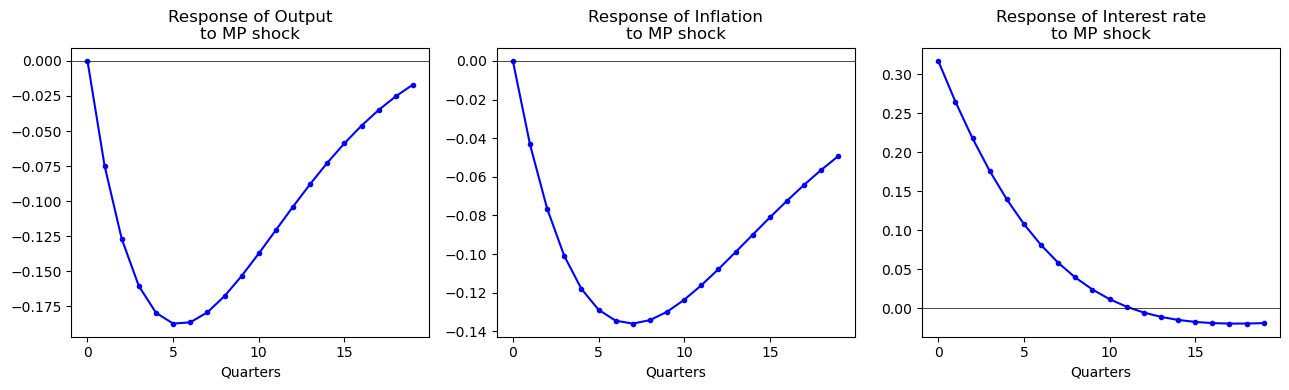

In [1]:
import numpy as np
from scipy.linalg import cholesky

np.random.seed(42)
n, T, p = 3, 200, 2

# True VAR(1) with monetary policy dynamics
A_true = np.array([[0.85, 0.02, -0.10],
                   [0.05, 0.90, -0.05],
                   [0.05, 0.10,  0.75]])
Sigma_true = np.array([[0.4, 0.1, 0.0],
                       [0.1, 0.2, 0.0],
                       [0.0, 0.0, 0.1]]) * 1e-4

L = cholesky(Sigma_true, lower=True)
Y = np.zeros((T, n))
for t in range(1, T):
    Y[t] = A_true @ Y[t-1] + L @ np.random.randn(n)

# OLS estimation (VAR(1))
X = Y[:-1]; Ytgt = Y[1:]
B_hat = np.linalg.lstsq(X, Ytgt, rcond=None)[0]  # (n×n) coefficient matrix
resid = Ytgt - X @ B_hat
Sigma_hat = resid.T @ resid / (T-1-n*p)

# Cholesky identification
P = cholesky(Sigma_hat, lower=True)  # B0^{-1} = P

# Compute IRFs
H = 20
e_mp = np.array([0, 0, 1])  # shock to interest rate
irf = np.zeros((H, n))
state = e_mp.copy()
for h in range(H):
    irf[h] = P @ state
    state = B_hat.T @ state  # B_hat is n×n: A @ state

import matplotlib.pyplot as plt
labels = ['Output', 'Inflation', 'Interest rate']
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for j, (ax, lab) in enumerate(zip(axes, labels)):
    ax.plot(range(H), irf[:,j]*100, 'b-o', markersize=3)
    ax.axhline(0, color='k', lw=0.5)
    ax.set_title(f'Response of {lab}\nto MP shock'); ax.set_xlabel('Quarters')
plt.tight_layout(); plt.show()

### APL

In [ ]:
⎕IO←0 ⋄ ⎕ML←1

⍝ --- 1. Native Cholesky Function ---
⍝ Computes Lower Triangular L such that L Lᵀ = Matrix
Cholesky ← {
    0=⍴⍴⍵: ⍵*0.5                       ⍝ If scalar, just square root
    1=1↑⍴⍵: ⍵*0.5                      ⍝ If 1x1 matrix, square root
    n ← 1↑⍴⍵
    L11 ← ∇ ⍵[0;0]
    L21 ← ⍵[1+⍳n-1;0] ÷ L11
    L22 ← ∇ ⍵[1+⍳n-1;1+⍳n-1] - L21 ∘.× L21
    (L11, ((n-1)⍴0)) ⍪ L21, L22
}

⍝ --- 2. Setup & Simulation ---
n←3 ⋄ T←200 ⋄ A_true←3 3 ⍴ 0.85 0.05 ¯0.1 0.02 0.9 ¯0.08 0.05 0.15 0.75
Y←T n ⍴ 0
:For t :In 1↓⍳T ⋄ Y[t;]←(Y[t-1;]+.×⍉A_true)+0.01×(?3⍴0)-0.5 ⋄ :EndFor

⍝ --- 3. OLS Estimation ---
X ← Y[⍳T-1;] 
Ytarget ← 1↓Y
B_hat ← (⌹X) +.× Ytarget

⍝ --- 4. Covariance & Identification ---
resid ← Ytarget - X +.× B_hat
Sigma ← ((⍉resid) +.× resid) ÷ (T - 1)
B0_inv ← Cholesky Sigma  ⍝ Pure APL Cholesky!

⍝ --- 5. Impulse Response (IRF) ---
H ← 20
e_mp ← 0 0 1  ⍝ Unit shock to 3rd variable (Interest Rate)

⍝ We calculate B_hat^h × (B0_inv × e_mp)
impact ← B0_inv +.× e_mp
irf_h ← {{B_hat +.× ⍵}⍣⍵ ⊢ impact} ¨ ⍳H

y_irf  ← {⍵[0]} ¨ irf_h
pi_irf ← {⍵[1]} ¨ irf_h
i_irf  ← {⍵[2]} ¨ irf_h

⍝ --- 6. Results ---
'Estimated Coefficients (B_hat):' ⋄ B_hat
'Output Response (y_irf):' ⋄ y_irf

### Julia

```julia
using LinearAlgebra, Statistics, Random

Random.seed!(42); n, T, p = 3, 200, 1
A_true = [0.85 0.02 -0.10; 0.05 0.90 -0.05; 0.05 0.10 0.75]
Sigma_t = [0.4 0.1 0; 0.1 0.2 0; 0 0 0.1] .* 1e-4
L = cholesky(Sigma_t).L
Y = zeros(T, n)
for t in 2:T; Y[t,:] = A_true * Y[t-1,:] + L * randn(n); end

X = Y[1:end-1,:]; Ytgt = Y[2:end,:]
B_hat = X \ Ytgt
resid = Ytgt - X * B_hat
Sigma_hat = resid' * resid / (T-1-n*p)
P = cholesky(Sigma_hat).L  # Cholesky identification

H = 20; e_mp = [0.0, 0.0, 1.0]
irf = zeros(H, n)
state = copy(e_mp)
for h in 1:H
    irf[h,:] = P * state
    state = B_hat' * state
end
println("Output IRF (quarters 1-5): ", round.(irf[1:5,1].*100, digits=3))
```

### R

```r
set.seed(42); n<-3; T<-200; p<-1
A_true<-matrix(c(0.85,0.05,0.05, 0.02,0.90,0.10, -0.10,-0.05,0.75),3,3)
Sigma_t<-matrix(c(0.4,0.1,0, 0.1,0.2,0, 0,0,0.1),3,3)*1e-4
L<-t(chol(Sigma_t))
Y<-matrix(0,T,n)
for(t in 2:T) Y[t,]<-A_true%*%Y[t-1,]+L%*%rnorm(n)

X<-Y[-T,]; Ytgt<-Y[-1,]
B_hat<-solve(crossprod(X))%*%crossprod(X,Ytgt)
resid<-Ytgt-X%*%B_hat; Sigma_hat<-crossprod(resid)/(T-2)
P<-t(chol(Sigma_hat))  # Cholesky lower

H<-20; e_mp<-c(0,0,1); irf<-matrix(0,H,n); state<-e_mp
for(h in 1:H){irf[h,]<-P%*%state; state<-t(B_hat)%*%state}
cat("Output IRF (1-5):", round(irf[1:5,1]*100,3))
```

---

## 19.8 Programming Exercises

### Exercise 19.1 (APL — VAR in One Expression)

Implement the full VAR($p$) estimation in APL as a dfn `var_ols ← {Y p ← ⍵ ⋄ ...}` that: (a) builds the lagged regressor matrix $X$ (of size $(T-p)\times np$ by stacking $p$ lags); (b) estimates $\hat{B} = (X'X)^{-1}X'Y$ using `⌹`; (c) computes residuals and $\hat\Sigma$; (d) returns the companion matrix $\tilde{A}$. Test on simulated data and verify eigenvalues of $\tilde{A}$ are inside the unit circle (stability).

### Exercise 19.2 (Python — ADF Test from Scratch)

```python
import numpy as np
from scipy.stats import t as t_dist

def adf_test(y, p=4, trend='c'):
    """ADF test with p augmentation lags; trend='c' or 'ct'."""
    T = len(y)
    dy = np.diff(y)    # first differences
    # Regressors: dy_{t-p}...dy_{t-1}, y_{t-1}, [1, t]
    lags = np.column_stack([dy[p-j:-j or None] for j in range(1, p+1)])
    y_lag = y[p:-1]
    dy_target = dy[p:]
    trend_cols = [np.ones(len(dy_target))]
    if trend == 'ct': trend_cols.append(np.arange(p+1, T))
    X = np.column_stack([y_lag] + [lags] + trend_cols)
    b = np.linalg.lstsq(X, dy_target, rcond=None)[0]
    resid = dy_target - X @ b
    s2 = resid @ resid / (len(dy_target) - X.shape[1])
    var_b = s2 * np.linalg.inv(X.T @ X)
    t_stat = b[0] / np.sqrt(var_b[0,0])  # t-stat on gamma (y_{t-1})
    # Approximate MacKinnon critical values
    cv_5pct = -2.86 if trend == 'c' else -3.41
    return t_stat, cv_5pct, t_stat < cv_5pct

# Test on I(1) series (should not reject)
T = 200
rw = np.cumsum(np.random.randn(T))
stat, cv, reject = adf_test(rw, p=2)
print(f"Random walk: t={stat:.3f}, cv={cv}, reject={reject}")

# Test on I(0) series (should reject)
ar1 = np.zeros(T)
for t in range(1,T): ar1[t] = 0.7*ar1[t-1] + np.random.randn()
stat2, cv2, reject2 = adf_test(ar1, p=2)
print(f"AR(1) ρ=0.7: t={stat2:.3f}, cv={cv2}, reject={reject2}")
```

### Exercise 19.3 (Julia — Johansen Test)

```julia
using LinearAlgebra

function johansen_trace(Y, p, r_max)
    # VECM: ΔY_t = ΠY_{t-1} + Γ_1 ΔY_{t-1} + ... + ε_t
    # Concentrated likelihood approach (Johansen 1988)
    T, n = size(Y)
    dY = diff(Y, dims=1)
    
    # Construct M00, M11, M01 via residuals of regressing dY and Y_{t-1} on lags
    # (Simplified: no short-run dynamics, p=1)
    Y_lag = Y[1:end-1, :]
    dY_use = dY
    T_ = size(dY_use, 1)
    
    M00 = (dY_use' * dY_use) / T_
    M11 = (Y_lag' * Y_lag) / T_
    M01 = (dY_use' * Y_lag) / T_
    
    # Eigenvalue problem: solve for eigenvalues of M11^{-1/2} M10 M00^{-1} M01 M11^{-1/2}
    M11_inv = inv(M11)
    eig_mat = M11_inv * M01' * inv(M00) * M01
    λ = sort(real(eigvals(eig_mat)), rev=true)
    
    # Trace statistic for H0: rank ≤ r
    trace_stats = [-T_*sum(log.(1 .- λ[r+1:end])) for r in 0:n-1]
    return λ, trace_stats
end

# Simulate cointegrated system: y = x + I(0), both I(1)
T = 300; n = 2
Y = zeros(T, n)
for t in 2:T
    Y[t,1] = Y[t-1,1] + randn()
    Y[t,2] = Y[t-1,1] + 0.5*randn()  # cointegrated: y₂ ≈ y₁
end

λ, tr = johansen_trace(Y, 1, 1)
println("Eigenvalues: ", round.(λ, digits=3))
println("Trace stats: ", round.(tr, digits=2))
println("95% CV (approx): [15.5, 3.8] for n=2")
# Trace(r=0) should exceed 15.5 → reject no cointegration
# Trace(r=1) should fall below 3.8 → do not reject r≤1
```

### Exercise 19.4 — Sign Restriction SVAR ($\star$)

Implement the Uhlig (2005) sign restriction identification for a three-variable VAR in $(y_t, \pi_t, i_t)$. (a) Estimate the reduced-form VAR and compute the Cholesky factor $P$. (b) For each of 1000 random orthogonal matrices $Q$ (drawn from the Haar measure), compute candidate impact matrices $B_0^{-1} = PQ$. (c) Keep only those $Q$ for which: monetary policy shock raises $i_t$ and reduces $y_t$ and $\pi_t$ on impact. (d) Compute the identified set of IRFs (the 16th and 84th percentiles across accepted draws). (e) Compare the identified set to the Cholesky point estimate.

---

## 19.9 Chapter Summary

**Key results:**

- $y_t \sim I(1)$ (unit root) means $\Delta y_t$ is stationary; OLS regressions in levels are spurious unless variables are cointegrated.
- The **ADF test** has $t$-statistic on $\hat\gamma$ in the augmented regression; non-standard critical values $\approx -2.86$ (constant, 5%).
- **Cointegration** is tested by Engle–Granger (OLS on levels, ADF on residuals) or Johansen (eigenvalue test on VECM); it implies a long-run equilibrium relationship.
- **VAR($p$) OLS estimation**: $\hat{B} = (X'X)^{-1}X'Y$ — in APL: `B ← (⌹ X) +.× Y`; IRF at horizon $h$: `A_companion⍣h +.× B0_inv +.× shock`.
- **Structural identification**: Cholesky (zero contemporaneous restrictions via triangular $P$), sign restrictions (set of accepted rotations), or proxy SVAR (external instrument).
- **Bootstrap confidence bands** resample residuals, reconstruct series, and re-estimate to form empirical distributions for IRFs.

*Next: Chapter 20 — The Kalman Filter*